<a href="https://colab.research.google.com/github/jotaeleb/tif-ciencias-de-datos/blob/main/notebooks/proyecto_entrenamiento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛡️TIF Análisis de Detección de Intrusiones en Red

**Grupo 1**: Gonza Gabriela · Casasola Hernán · Biazutti Luciano · Lera Aníbal Iván · Alvarado Marcelo

**Módulo**: Ciencias de Datos y Optimización de Modelos

**Carrera**: Tecnicatura Universitaria en Ciencias de Datos e IA Aplicada — UPATECO

---



En esta notebook continuamos el trabajo iniciado en proyecto_eda.ipynb.  
El objetivo es construir modelos que puedan **detectar automáticamente** si un flujo de red es benigno o un ataque.

# 1. Preparación de los Datos

## 1.1 Librerías

In [27]:
# Librerías generales
import io
import warnings
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Librerías de scikit-learn para modelado
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder, StandardScaler

warnings.filterwarnings('ignore')

# Colores consistentes con la Entrega 1
COLOR_BENIGNO = '#A1D99B'
COLOR_ATAQUE  = '#F8766D'
COLOR_NEUTRO  = '#AED6F1'

## 1.2 Carga del dataset
Con 2,8 millones de filas, entrenar modelos en Colab puede consumir demasiada memoria y tiempo. Por eso vamos a utilizar una muestra estratificada de 150.000 filas, que mantiene la proporción original de las clases y permite obtener resultados representativos con menor costo computacional.

La muestra df_muestra.parquet se carga directamente desde GitHub y ya se encuentra limpia, sin valores nulos ni columnas problemáticas, según el análisis realizado en proyecto_eda.ipynb.

In [20]:
# Configuración
GITHUB_USER   = 'jotaeleb'
GITHUB_REPO   = 'tif-ciencias-de-datos'
GITHUB_BRANCH = 'main'
DATASET_DIR   = 'dataset'

BASE_URL = (
    f'https://raw.githubusercontent.com/'
    f'{GITHUB_USER}/{GITHUB_REPO}/{GITHUB_BRANCH}/{DATASET_DIR}'
)

FILE_NAME = 'df_muestra.parquet'

# Cargar dataset
url = f'{BASE_URL}/{FILE_NAME}'
df = pd.read_parquet(io.BytesIO(requests.get(url).content))

# Variables
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()

# Resumen
print(f'Dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'Variables numéricas: {len(num_cols)} | Variables categóricas: {len(cat_cols)}')
print(f'BENIGN: {(df["Label"] == "BENIGN").mean()*100:.2f}%')

Dataset: 149,990 filas × 64 columnas
Variables numéricas: 63 | Variables categóricas: 1
BENIGN: 80.32%


# 2. PRIMERA ITERACIÓN


## 2.1 Preparación: variables y codificación

Los modelos de scikit-learn trabajan con números, no con texto. Necesitamos:
1. Seleccionar las columnas numéricas que usaremos como predictores
2. Convertir la variable objetivo `Label` a números
3. Separar en conjunto de entrenamiento y de prueba

In [38]:
# Vista rápida de las primeras filas
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', None)
df.head(3)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Fwd URG Flags,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Subflow Fwd Bytes,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,es_ataque
0,53,206,2,2,68,132,34,34,34.00,0.00,66,66,66.00,0.00,970873.79,19417.48,68.67,113.74,200,3,3,3.00,0.00,3,3,3,3.00,0.00,3,3,0,0,9708.74,9708.74,34,66,46.80,17.53,307.20,0,0,0,0,0,0,1,58.50,34.00,66.00,68,132,-1,-1,1,32,0.00,0.00,0,0,0.00,0.00,0,0,BENIGN,0
1,443,676974,9,6,1697,1221,1349,0,188.56,441.13,1069,2,203.50,425.30,4310.36,22.16,48355.29,47275.83,118426,4,676974,84621.75,64370.78,207316,4,459769,91953.80,97240.60,198671,1280,0,0,13.29,8.86,0,1349,182.38,408.04,166498.65,0,0,1,0,0,0,0,194.53,188.56,203.50,1697,1221,8192,65535,8,20,0.00,0.00,0,0,0.00,0.00,0,0,BENIGN,0
2,443,63161627,7,0,0,0,0,0,0.00,0.00,0,0,0.00,0.00,0.00,0.11,10500000.00,11900000.00,32100000,997609,63200000,10500000.00,11900000.00,32100000,997609,0,0.00,0.00,0,0,0,0,0.11,0.00,0,0,0.00,0.00,0.00,0,0,1,0,0,0,0,0.00,0.00,0.00,0,0,29200,-1,0,40,7009617.00,0.00,7009617,7009617,18700000.00,12300000.00,32100000,8023974,BENIGN,0


In [24]:
# 1. Seleccionamos las variables
features = num_cols.copy()
X = df[features].copy()

# 2. Convertimos los labels de texto a números (LabelEncoder)
le = LabelEncoder()
y = le.fit_transform(df['Label'])

print('Clases codificadas:')
for i, clase in enumerate(le.classes_):
    print(f'  {i} → {clase}')

print(f'\nForma de X: {X.shape}')
print(f'Forma de y: {y.shape}')

Clases codificadas:
  0 → BENIGN
  1 → Bot
  2 → DDoS
  3 → DoS GoldenEye
  4 → DoS Hulk
  5 → DoS Slowhttptest
  6 → DoS slowloris
  7 → FTP-Patator
  8 → Infiltration
  9 → PortScan
  10 → SSH-Patator
  11 → Web Attack - Brute Force
  12 → Web Attack - Sql Injection
  13 → Web Attack - XSS

Forma de X: (149990, 63)
Forma de y: (149990,)


In [28]:
# Identificar clases con menos de 2 muestras
class_counts = Counter(y)
singleton_classes = [idx for idx, count in class_counts.items() if count < 2]

if singleton_classes:
    print("Clases con 1 sola muestra encontradas.")

    # Crear máscaras para separar los datos
    # Asumiendo que 'y' puede ser convertido a un array de numpy o es una Serie de Pandas
    y_array = np.array(y)
    is_singleton = np.isin(y_array, singleton_classes)

    # Extraer las muestras únicas (usamos boolean indexing)
    # Nota: Ajusta esto si X es un numpy array en lugar de un DataFrame (usando X[is_singleton])
    if isinstance(X, pd.DataFrame):
        X_singletons = X[is_singleton]
    else:
        X_singletons = X[is_singleton] # Funciona igual para numpy arrays

    y_singletons = y_array[is_singleton]

    # Extraer el resto de los datos (los que sí se pueden estratificar)
    if isinstance(X, pd.DataFrame):
        X_rest = X[~is_singleton]
    else:
        X_rest = X[~is_singleton]

    y_rest = y_array[~is_singleton]

    print(f"Muestras únicas separadas: {len(y_singletons)}")
    print(f"Muestras restantes para estratificar: {len(y_rest)}")

    # Aplicar train_test_split SOLO al "resto" de los datos
    X_train_rest, X_test, y_train_rest, y_test = train_test_split(
        X_rest, y_rest, test_size=0.2, random_state=42, stratify=y_rest
    )

    # Añadir las muestras únicas de vuelta al conjunto de ENTRENAMIENTO
    if isinstance(X, pd.DataFrame):
        X_train = pd.concat([X_train_rest, X_singletons], ignore_index=True)
    else:
        X_train = np.vstack((X_train_rest, X_singletons))

    y_train = np.concatenate([y_train_rest, y_singletons])

else:
    # Si no hay clases problemáticas, usar el flujo normal
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    print("No se encontraron clases con menos de 2 muestras.")

print(f'\nDimensiones finales:')
print(f'Filas de entrenamiento: {X_train.shape[0]:,}')
print(f'Filas de prueba: {X_test.shape[0]:,}')

Clases con 1 sola muestra encontradas.
Muestras únicas separadas: 2
Muestras restantes para estratificar: 149988

Dimensiones finales:
Filas de entrenamiento: 119,992
Filas de prueba: 29,998


## 2.2 Entrenamiento del modelo base

El Árbol de Decisión es uno de los modelos más **fáciles de entender e interpretar**. Es ideal para comenzar porque no requiere normalizar los datos y sus resultados son explicables.

In [29]:
# Creamos el árbol de decisión con profundidad limitada (max_depth=5)
# Limitar la profundidad evita que el modelo sea demasiado complejo (sobreajuste)
arbol = DecisionTreeClassifier(max_depth=5, random_state=42)

# Entrenamos el modelo con los datos de entrenamiento
arbol.fit(X_train, y_train)

print('Modelo entrenado')
print(f'Profundidad real del árbol: {arbol.get_depth()}')
print(f'Número de nodos: {arbol.tree_.node_count}')

Modelo entrenado
Profundidad real del árbol: 5
Número de nodos: 47


## 2.3 Visualización del árbol

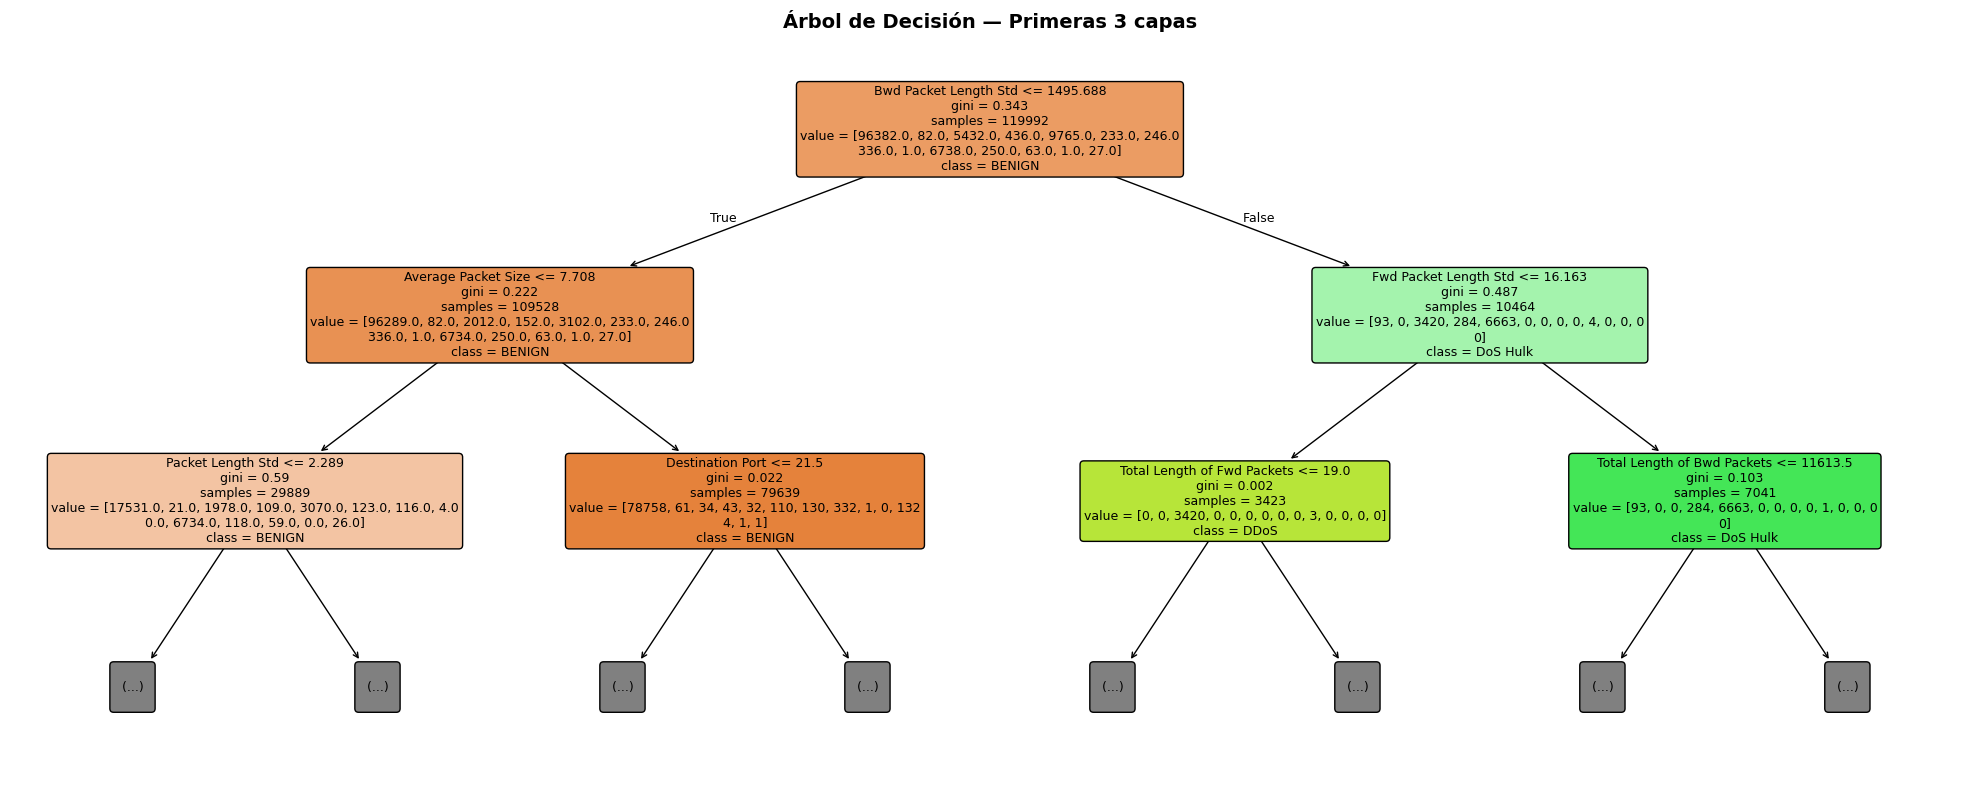

In [30]:
fig, ax = plt.subplots(figsize=(20, 8))

# Graficamos el árbol mostrando solo las primeras 2 capas para que sea legible
plot_tree(
    arbol,
    max_depth=2,
    feature_names=features,         # Nombres de las variables
    class_names=le.classes_,        # Nombres de las clases
    filled=True,                    # Colorear los nodos según la clase dominante
    rounded=True,
    fontsize=9,
    ax=ax
)

ax.set_title('Árbol de Decisión — Primeras 3 capas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Cada nodo muestra la variable y el umbral que usa para dividir los datos. Los colores representan la clase dominante en ese grupo. Los nodos más "puros" (de un solo color) indican que el modelo está diferenciando bien las clases.

## 2.4 Evaluación del modelo

Usamos tres métricas principales:
- **Accuracy (exactitud)**: porcentaje de predicciones correctas en total
- **Precision**: de todos los que predije como ataque, ¿cuántos realmente lo eran?
- **Recall**: de todos los ataques reales, ¿cuántos detecté?

In [36]:
# Generamos predicciones sobre el conjunto de prueba
y_pred = arbol.predict(X_test)

# Accuracy: porcentaje de aciertos totales
accuracy = (y_pred == y_test).mean()
print(f'Accuracy del modelo: {accuracy:.2%}\n')

# Obtenemos todos los índices posibles de las clases originales
todas_las_clases = np.arange(len(le.classes_))

# Reporte de clasificación (opcionalmente ajustado a las clases presentes)
unique_labels_in_test = np.unique(np.concatenate([y_test, y_pred]))
filtered_target_names = le.inverse_transform(unique_labels_in_test)

print('Reporte de clasificación:')
print(classification_report(y_test, y_pred, labels=unique_labels_in_test, target_names=filtered_target_names))

Accuracy del modelo: 96.58%

Reporte de clasificación:
                          precision    recall  f1-score   support

                  BENIGN       0.96      1.00      0.98     24096
                     Bot       0.00      0.00      0.00        21
                    DDoS       1.00      0.99      1.00      1358
           DoS GoldenEye       0.98      0.58      0.73       109
                DoS Hulk       0.96      0.72      0.82      2441
        DoS Slowhttptest       0.85      0.19      0.31        58
           DoS slowloris       1.00      0.34      0.51        61
             FTP-Patator       0.99      1.00      0.99        84
                PortScan       1.00      0.99      0.99      1685
             SSH-Patator       0.00      0.00      0.00        62
Web Attack - Brute Force       0.00      0.00      0.00        16
        Web Attack - XSS       0.00      0.00      0.00         7

                accuracy                           0.97     29998
               macr

## 2.5 Matriz de Confusión

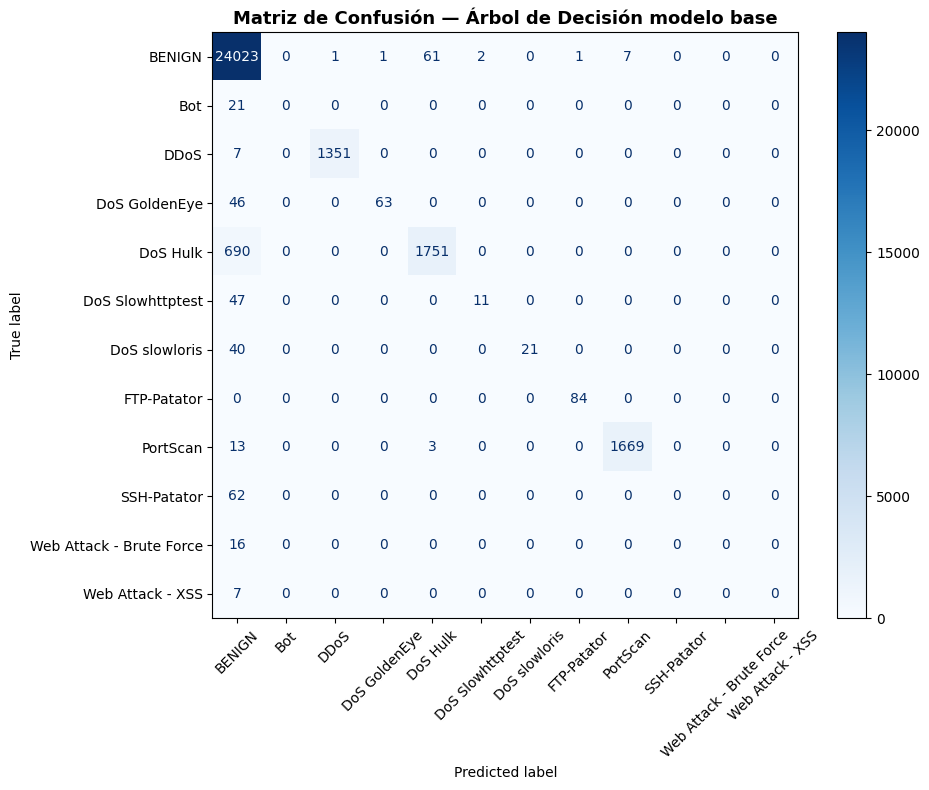

In [37]:
# Calculamos la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))

# Usamos los nombres de las clases que realmente están presentes en el conjunto de prueba
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=filtered_target_names)
disp.plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation=45)

ax.set_title('Matriz de Confusión — Árbol de Decisión modelo base', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

La diagonal principal muestra los casos correctamente clasificados. Los valores fuera de la diagonal son errores. Si vemos que ciertos ataques se confunden con BENIGN, ese es el principal problema a mejorar.

## 2.6 Importancia de variables

El árbol de decisión puede decirnos qué tanto usó cada variable en sus decisiones. Esto nos ayuda a entender el problema e identificar variables importantes para el modelo.

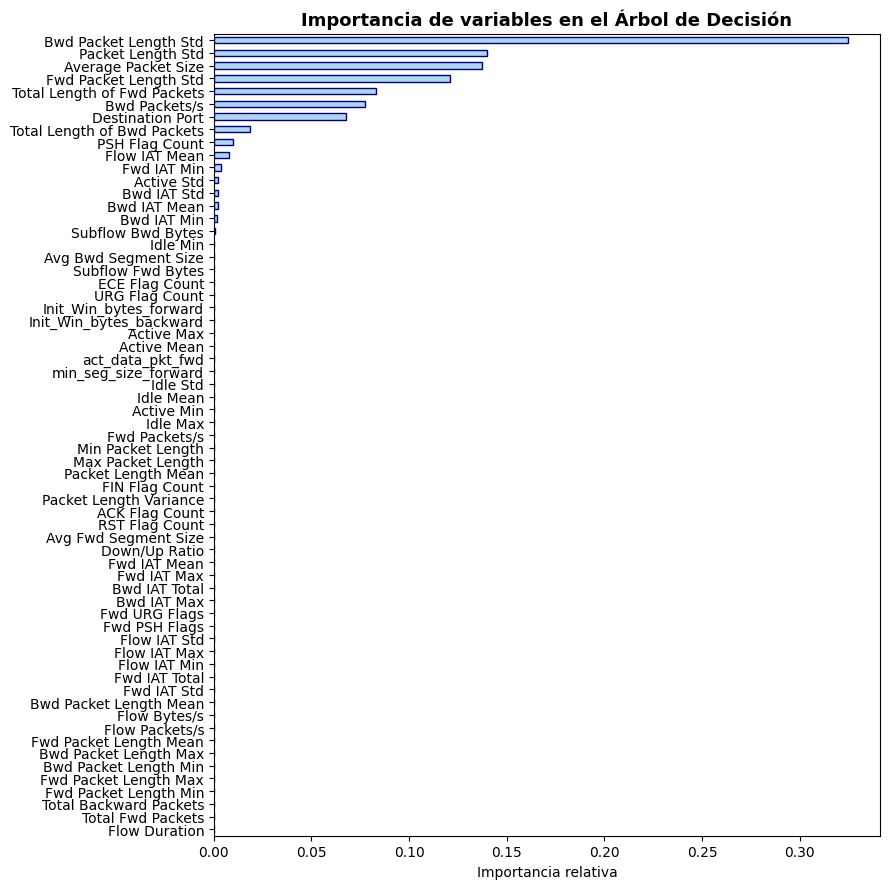


Top 3 variables más importantes:
Bwd Packet Length Std   0.32
Packet Length Std       0.14
Average Packet Size     0.14
dtype: float64


In [35]:
# Extraemos la importancia de cada variable
importancias = pd.Series(arbol.feature_importances_, index=features)
importancias = importancias.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 9))
importancias.plot(kind='barh', ax=ax, color=COLOR_NEUTRO, edgecolor='navy')

ax.set_title('Importancia de variables en el Árbol de Decisión', fontsize=13, fontweight='bold')
ax.set_xlabel('Importancia relativa')
ax.axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

print('\nTop 3 variables más importantes:')
print(importancias.sort_values(ascending=False).head(3))

# 3. SEGUNDA ITERACIÓN

# 3. OPTIMIZACION DEL MODELO